In [22]:
# Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import OneHotEncoder, MinMaxScaler
from sklearn.decomposition import PCA
from IPython.display import clear_output
from sklearn.metrics import silhouette_score

In [23]:
# Load the dataset
df_airbnb = pd.read_csv('airbnb.csv')
df_airbnb.head()

,id,name,host_id,host_name,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365
0,2539,Clean & quiet apt home by the park,2787,John,Brooklyn,Kensington,40.64749,-73.97237,Private room,149,1,9,10/19/2018,0.21,6,365
1,2595,Skylit Midtown Castle,2845,Jennifer,Manhattan,Midtown,40.75362,-73.98377,Entire home/apt,225,1,45,5/21/2019,0.38,2,355
2,3647,THE VILLAGE OF HARLEM....NEW YORK !,4632,Elisabeth,Manhattan,Harlem,40.80902,-73.94190,Private room,150,3,0,NaN,NaN,1,365
3,3831,Cozy Entire Floor of Brownstone,4869,LisaRoxanne,Brooklyn,Clinton Hill,40.68514,-73.95976,Entire home/apt,89,1,270,7/5/2019,4.64,1,194
4,5022,Entire Apt: Spacious Studio/Loft by central park,7192,Laura,Manhattan,East Harlem,40.79851,-73.94399,Entire home/apt,80,10,9,11/19/2018,0.10,1,0


In [24]:
# Check for Nan values
df_airbnb.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48895 entries, 0 to 48894
Data columns (total 16 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   id                              48895 non-null  int64  
 1   name                            48879 non-null  object 
 2   host_id                         48895 non-null  int64  
 3   host_name                       48874 non-null  object 
 4   neighbourhood_group             48895 non-null  object 
 5   neighbourhood                   48895 non-null  object 
 6   latitude                        48895 non-null  float64
 7   longitude                       48895 non-null  float64
 8   room_type                       48895 non-null  object 
 9   price                           48895 non-null  int64  
 10  minimum_nights                  48895 non-null  int64  
 11  number_of_reviews               48895 non-null  int64  
 12  last_review                     

In [25]:
df_airbnb.isnull().sum()

id                                    0
name                                 16
host_id                               0
host_name                            21
neighbourhood_group                   0
neighbourhood                         0
latitude                              0
longitude                             0
room_type                             0
price                                 0
minimum_nights                        0
number_of_reviews                     0
last_review                       10052
reviews_per_month                 10052
calculated_host_listings_count        0
availability_365                      0
dtype: int64

In [26]:
# Fill Nan values with 0
df_airbnb["reviews_per_month"] = df_airbnb["reviews_per_month"].fillna(0)

df_airbnb.isnull().sum()

id                                    0
name                                 16
host_id                               0
host_name                            21
neighbourhood_group                   0
neighbourhood                         0
latitude                              0
longitude                             0
room_type                             0
price                                 0
minimum_nights                        0
number_of_reviews                     0
last_review                       10052
reviews_per_month                     0
calculated_host_listings_count        0
availability_365                      0
dtype: int64

In [27]:
# Create DataFrame with features used for clustering
features = [
    "neighbourhood_group", "latitude", "longitude", "room_type", "price", "minimum_nights", "number_of_reviews", "reviews_per_month",
    "calculated_host_listings_count", "availability_365"
    ]

In [28]:
data = df_airbnb[features].copy()

data.head()

,neighbourhood_group,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,reviews_per_month,calculated_host_listings_count,availability_365
0,Brooklyn,40.64749,-73.97237,Private room,149,1,9,0.21,6,365
1,Manhattan,40.75362,-73.98377,Entire home/apt,225,1,45,0.38,2,355
2,Manhattan,40.80902,-73.94190,Private room,150,3,0,0.00,1,365
3,Brooklyn,40.68514,-73.95976,Entire home/apt,89,1,270,4.64,1,194
4,Manhattan,40.79851,-73.94399,Entire home/apt,80,10,9,0.10,1,0


In [29]:
data.isnull().sum()

neighbourhood_group               0
latitude                          0
longitude                         0
room_type                         0
price                             0
minimum_nights                    0
number_of_reviews                 0
reviews_per_month                 0
calculated_host_listings_count    0
availability_365                  0
dtype: int64

In [30]:
# Remove outlier
data.describe()

,latitude,longitude,price,minimum_nights,number_of_reviews,reviews_per_month,calculated_host_listings_count,availability_365
count,48895.000000,48895.000000,48895.000000,48895.000000,48895.000000,48895.000000,48895.000000,48895.000000
mean,40.728949,-73.952170,152.720687,7.029962,23.274466,1.090910,7.143982,112.781327
std,0.054530,0.046157,240.154170,20.510550,44.550582,1.597283,32.952519,131.622289
min,40.499790,-74.244420,0.000000,1.000000,0.000000,0.000000,1.000000,0.000000
25%,40.690100,-73.983070,69.000000,1.000000,1.000000,0.040000,1.000000,0.000000
50%,40.723070,-73.955680,106.000000,3.000000,5.000000,0.370000,1.000000,45.000000
75%,40.763115,-73.936275,175.000000,5.000000,24.000000,1.580000,2.000000,227.000000
max,40.913060,-73.712990,10000.000000,1250.000000,629.000000,58.500000,327.000000,365.000000


**Note:**
- Extreme outliers were observed in variables such as price, number of reviews, review per month counts, and host listings count. These were removed using the 99th percentile threshold to improve clustering stability.

In [31]:
# Remove extreme outliers using the 99th percentile
data = data[
    (data['price'] < data['price'].quantile(0.99)) &
    (data['minimum_nights'] < data['minimum_nights'].quantile(0.99)) &
    (data['number_of_reviews'] < data['number_of_reviews'].quantile(0.99)) &
    (data['reviews_per_month'] < data['reviews_per_month'].quantile(0.99)) &
    (data['calculated_host_listings_count'] < data['calculated_host_listings_count'].quantile(0.99))
]

data.describe()

,latitude,longitude,price,minimum_nights,number_of_reviews,reviews_per_month,calculated_host_listings_count,availability_365
count,46460.000000,46460.000000,46460.000000,46460.000000,46460.000000,46460.000000,46460.000000,46460.000000
mean,40.728861,-73.951670,136.236246,5.621373,20.742144,1.002007,3.941261,108.219802
std,0.054912,0.045718,102.539854,8.227813,35.615693,1.347339,12.528928,130.071966
min,40.499790,-74.244420,0.000000,1.000000,0.000000,0.000000,1.000000,0.000000
25%,40.689700,-73.982250,68.000000,1.000000,1.000000,0.040000,1.000000,0.000000
50%,40.722830,-73.955140,103.000000,3.000000,5.000000,0.370000,1.000000,37.000000
75%,40.763373,-73.935718,175.000000,5.000000,23.000000,1.500000,2.000000,212.000000
max,40.913060,-73.712990,795.000000,44.000000,213.000000,6.790000,121.000000,365.000000


In [32]:
data.isnull().sum()

neighbourhood_group               0
latitude                          0
longitude                         0
room_type                         0
price                             0
minimum_nights                    0
number_of_reviews                 0
reviews_per_month                 0
calculated_host_listings_count    0
availability_365                  0
dtype: int64

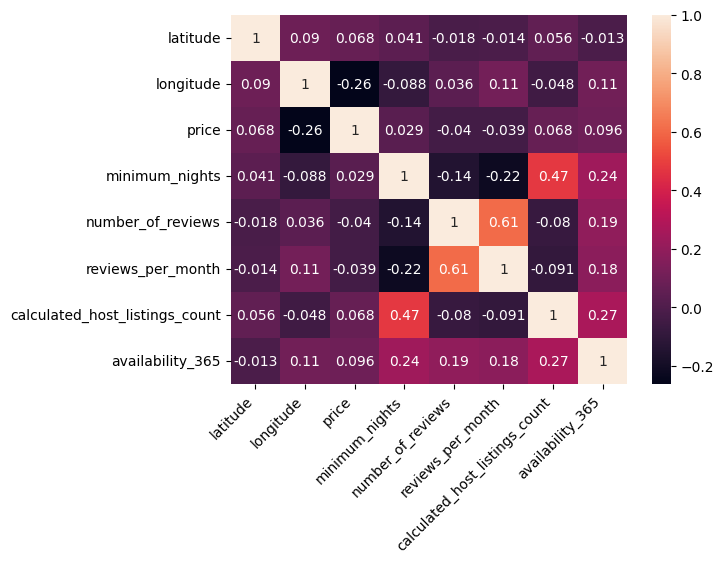

In [33]:
corr_matrix = data.corr(numeric_only=True)

sns.heatmap(corr_matrix, annot=True)

plt.xticks(rotation=45, ha='right')
plt.show()

- Dimensionality reduction was not required for clustering, as the dataset contains a small number of features with low multicollinearity. 

In [34]:
# Encoding categorical data
categorical_cols = ['neighbourhood_group', 'room_type']

encoder = OneHotEncoder(
    handle_unknown='ignore',
    sparse_output=False,
    drop='first'
)

encoded = encoder.fit_transform(data[categorical_cols])

encoded_df = pd.DataFrame(
    encoded,
    columns=encoder.get_feature_names_out(categorical_cols),
    index=data.index
)

data = pd.concat(
    [
        data.drop(columns=categorical_cols),
        encoded_df
    ],
    axis=1
)

data.head()

,latitude,longitude,price,minimum_nights,number_of_reviews,reviews_per_month,calculated_host_listings_count,availability_365,neighbourhood_group_Brooklyn,neighbourhood_group_Manhattan,neighbourhood_group_Queens,neighbourhood_group_Staten Island,room_type_Private room,room_type_Shared room
0,40.64749,-73.97237,149,1,9,0.21,6,365,1.0,0.0,0.0,0.0,1.0,0.0
1,40.75362,-73.98377,225,1,45,0.38,2,355,0.0,1.0,0.0,0.0,0.0,0.0
2,40.80902,-73.94190,150,3,0,0.00,1,365,0.0,1.0,0.0,0.0,1.0,0.0
4,40.79851,-73.94399,80,10,9,0.10,1,0,0.0,1.0,0.0,0.0,0.0,0.0
5,40.74767,-73.97500,200,3,74,0.59,1,129,0.0,1.0,0.0,0.0,0.0,0.0


### K-mean Clustering
1. Scale the data
2. Initialize random centroids
3. Label each data point
4. Update centroids
5. Repeat step 3 and step 4 until centroids stop changing

In [35]:
# Step 1: Scale the data
scaler = MinMaxScaler()

data_scaled = scaler.fit_transform(data)

data_scaled = pd.DataFrame(
    data_scaled, 
    columns=data.columns,
    index=data.index
    )

data_scaled.head()

,latitude,longitude,price,minimum_nights,number_of_reviews,reviews_per_month,calculated_host_listings_count,availability_365,neighbourhood_group_Brooklyn,neighbourhood_group_Manhattan,neighbourhood_group_Queens,neighbourhood_group_Staten Island,room_type_Private room,room_type_Shared room
0,0.357393,0.511921,0.187421,0.000000,0.042254,0.030928,0.041667,1.000000,1.0,0.0,0.0,0.0,1.0,0.0
1,0.614199,0.490469,0.283019,0.000000,0.211268,0.055965,0.008333,0.972603,0.0,1.0,0.0,0.0,0.0,0.0
2,0.748252,0.569257,0.188679,0.046512,0.000000,0.000000,0.000000,1.000000,0.0,1.0,0.0,0.0,1.0,0.0
4,0.722820,0.565324,0.100629,0.209302,0.042254,0.014728,0.000000,0.000000,0.0,1.0,0.0,0.0,0.0,0.0
5,0.599802,0.506972,0.251572,0.046512,0.347418,0.086892,0.000000,0.353425,0.0,1.0,0.0,0.0,0.0,0.0


In [36]:
data_scaled.describe()  

,latitude,longitude,price,minimum_nights,number_of_reviews,reviews_per_month,calculated_host_listings_count,availability_365,neighbourhood_group_Brooklyn,neighbourhood_group_Manhattan,neighbourhood_group_Queens,neighbourhood_group_Staten Island,room_type_Private room,room_type_Shared room
count,46460.000000,46460.000000,46460.000000,46460.000000,46460.000000,46460.000000,46460.000000,46460.000000,46460.000000,46460.000000,46460.000000,46460.000000,46460.000000,46460.000000
mean,0.554288,0.550873,0.171366,0.107474,0.097381,0.147571,0.024511,0.296493,0.419759,0.433663,0.116207,0.007706,0.464270,0.024193
std,0.132873,0.086028,0.128981,0.191344,0.167210,0.198430,0.104408,0.356362,0.493525,0.495585,0.320477,0.087443,0.498727,0.153649
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.459530,0.493329,0.085535,0.000000,0.004695,0.005891,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,0.539696,0.544343,0.129560,0.046512,0.023474,0.054492,0.000000,0.101370,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,0.637797,0.580890,0.220126,0.093023,0.107981,0.220913,0.008333,0.580822,1.000000,1.000000,0.000000,0.000000,1.000000,0.000000
max,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


In [37]:
# Step 2: Intialize random centroids
def random_centroids(data, k, random_state=42):
    return data.sample(n=k, random_state=random_state).reset_index(drop=True)

centroids = random_centroids(data_scaled, 5)

centroids

,latitude,longitude,price,minimum_nights,number_of_reviews,reviews_per_month,calculated_host_listings_count,availability_365,neighbourhood_group_Brooklyn,neighbourhood_group_Manhattan,neighbourhood_group_Queens,neighbourhood_group_Staten Island,room_type_Private room,room_type_Shared room
0,0.609335,0.679807,0.069182,0.023256,0.197183,0.153166,0.000000,0.323288,0.0,0.0,1.0,0.0,1.0,0.0
1,0.592905,0.461491,0.213836,0.093023,0.061033,0.044183,0.000000,0.010959,0.0,1.0,0.0,0.0,0.0,0.0
2,0.738452,0.561692,0.182390,0.046512,0.004695,0.092784,0.041667,1.000000,0.0,1.0,0.0,0.0,1.0,0.0
3,0.885281,0.601321,0.050314,0.023256,0.014085,0.061856,0.000000,0.052055,0.0,1.0,0.0,0.0,1.0,0.0
4,0.436518,0.489886,0.201258,0.000000,0.004695,0.147275,0.058333,0.997260,1.0,0.0,0.0,0.0,1.0,0.0


In [38]:
# Step 3: Label each data point
def get_labels(data, centroids):
    distances = centroids.apply(
        lambda x: np.sqrt(((data - x)**2).sum(axis=1)), axis=1).T
    return distances.idxmin(axis=1)

labels = get_labels(data_scaled, centroids)

In [39]:
labels.value_counts()

4    18321
1    14284
3     5958
0     5646
2     2251
Name: count, dtype: int64

In [40]:
# Step 4: Update centroids
def update_centroids(data, labels, k):
    centroids = data.groupby(labels).mean()
    centroids = centroids.reindex(range(k))
    empty_clusters = centroids[centroids.isnull().any(axis=1)].index
    for cluster_id in empty_clusters:
        centroids.loc[cluster_id] = data.sample(n=1).iloc[0]
    return centroids.sort_index()

new_centroids = update_centroids(data_scaled, labels, k=5)

new_centroids

,latitude,longitude,price,minimum_nights,number_of_reviews,reviews_per_month,calculated_host_listings_count,availability_365,neighbourhood_group_Brooklyn,neighbourhood_group_Manhattan,neighbourhood_group_Queens,neighbourhood_group_Staten Island,room_type_Private room,room_type_Shared room
0,0.566254,0.691106,0.117289,0.081877,0.106620,0.193024,0.025491,0.388545,0.000000,0.000000,0.956252,0.012398,0.613000,0.033298
1,0.618872,0.508026,0.255322,0.159105,0.078861,0.119768,0.046430,0.268560,0.091081,0.870905,0.000000,0.011761,0.000000,0.035634
2,0.694301,0.538747,0.153978,0.106971,0.142578,0.184874,0.040571,0.833908,0.000000,0.882719,0.000000,0.000000,0.959574,0.016437
3,0.675807,0.525916,0.122321,0.065228,0.086549,0.138920,0.005858,0.086027,0.000000,0.960222,0.000000,0.000000,1.000000,0.000000
4,0.443526,0.550669,0.140662,0.088908,0.106943,0.153470,0.011211,0.292317,0.993450,0.000000,0.000000,0.006550,0.545330,0.021287


In [41]:
# Compute sse to construct Elbow plot
def compute_sse(data, labels, centroids):
    sse = 0
    for i in range(len(centroids)):
        cluster_points = data[labels == i]
        if len(cluster_points) > 0:
            sse += ((cluster_points - centroids.iloc[i]) ** 2).sum().sum()
    return sse


In [48]:
# Step 5: Run the K-means to convergence, with multiple random initializations
# (keep the lowest-SSE run, since a single random init can land in a bad local minimum)
def run_kmeans(data, k, n_init=10, max_iterations=100, random_state=42):
    rng = np.random.default_rng(random_state)

    best_sse = None
    best_labels = None
    best_centroids = None

    for _ in range(n_init):
        seed = int(rng.integers(0, 1_000_000))
        centroids = random_centroids(data, k, random_state=seed)

        for _ in range(max_iterations):
            labels = get_labels(data, centroids)
            new_centroids = update_centroids(data, labels, k)

            if np.allclose(new_centroids.values, centroids.values, atol=1e-6):
                centroids = new_centroids
                break

            centroids = new_centroids

        labels = get_labels(data, centroids)
        sse = compute_sse(data, labels, centroids)

        if  best_sse is None or sse < best_sse:
            best_sse = sse
            best_labels = labels
            best_centroids = centroids

    return best_labels, best_centroids, best_sse

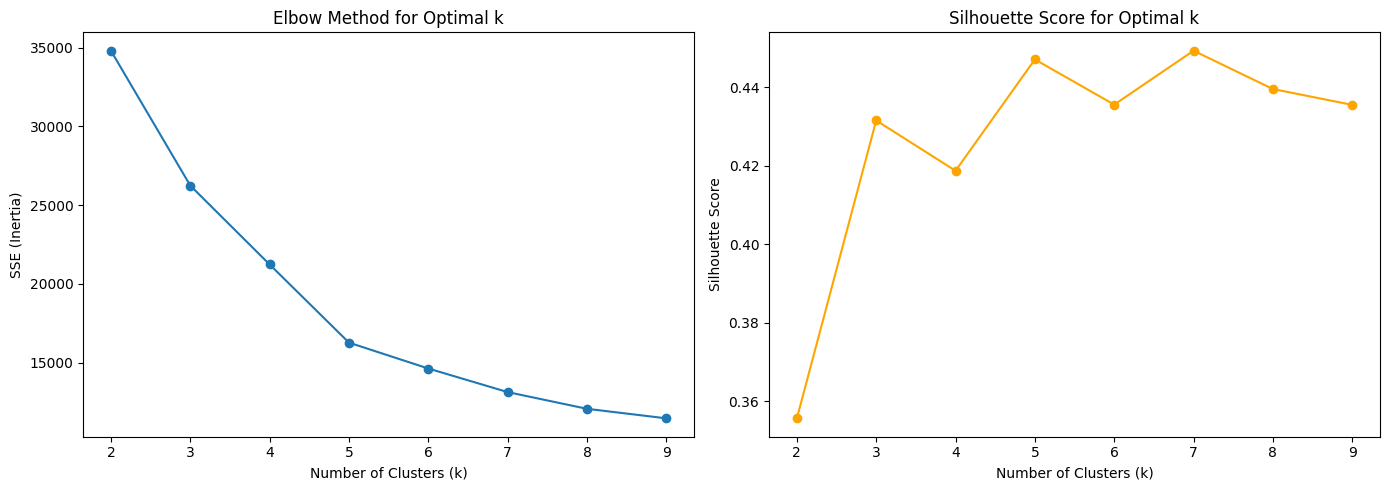

In [49]:
# Construct the Elbow Plot and Silhouette Score for different values of k
k_values = range(2, 10)
sse_values = []
silhouette_values = []

for k in k_values:
    labels, centroids, sse = run_kmeans(data_scaled, k, n_init=10, random_state=42)
    sse_values.append(sse)
    
    sample_size = min(5000, len(data_scaled))
    sil_score = silhouette_score(data_scaled, labels, sample_size=sample_size, random_state=42)
    silhouette_values.append(sil_score)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(k_values, sse_values, marker='o')
axes[0].set_xlabel("Number of Clusters (k)")
axes[0].set_ylabel("SSE (Inertia)")
axes[0].set_title("Elbow Method for Optimal k")

axes[1].plot(k_values, silhouette_values, marker='o', color='orange')
axes[1].set_xlabel("Number of Clusters (k)")
axes[1].set_ylabel("Silhouette Score")
axes[1].set_title("Silhouette Score for Optimal k")

plt.tight_layout()
plt.show()

In [51]:
# Choose k based on the Elbow plot and Silhouette score
k = 7

final_labels, final_centroids, final_sse = run_kmeans(data_scaled, k, n_init=10, random_state=42)

print(f"Final SSE: {final_sse:.2f}")
print(final_labels.value_counts())

Final SSE: 13137.72
3    9878
2    9624
1    8512
5    7660
6    4032
0    3982
4    2772
Name: count, dtype: int64


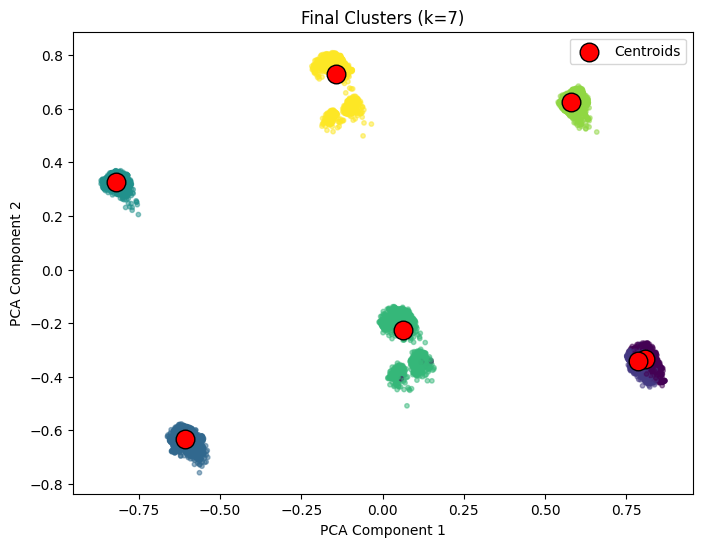

In [52]:
# Define a function to visualize the final clusters using PCA for dimensionality reduction
def plot_clusters(data, labels, centroids, k):
    pca = PCA(n_components=2)
    data_2D = pca.fit_transform(data)
    centroids_2D = pca.transform(centroids)

    plt.figure(figsize=(8, 6))
    plt.title(f"Final Clusters (k={k})")

    plt.scatter(
        x=data_2D[:, 0],
        y=data_2D[:, 1],
        c=labels,
        cmap='viridis',
        alpha=0.5,
        s=10
    )

    plt.scatter(
        x=centroids_2D[:, 0],
        y=centroids_2D[:, 1],
        s=180,
        c='red',
        edgecolors='black',
        label='Centroids'
    )

    plt.xlabel("PCA Component 1")
    plt.ylabel("PCA Component 2")
    plt.legend()
    plt.show()

plot_clusters(data_scaled, final_labels, final_centroids, k)

In [53]:
# Cluster Profiling: describe each cluster's characteristics based on the original features
profile_df = df_airbnb.loc[final_labels.index, features].copy()
profile_df['cluster'] = final_labels.values

numeric_cols = [
    "price", "minimum_nights", "number_of_reviews", "reviews_per_month",
    "calculated_host_listings_count", "availability_365"
]

cluster_profile = profile_df.groupby('cluster')[numeric_cols].mean().round(2)
cluster_profile['count'] = profile_df['cluster'].value_counts()

cluster_profile

,price,minimum_nights,number_of_reviews,reviews_per_month,calculated_host_listings_count,availability_365,count
cluster,,,,,,,
0,233.75,15.47,23.96,1.01,19.72,282.25,3982
1,198.60,4.52,14.26,0.77,1.51,25.80,8512
2,161.09,5.38,24.62,1.05,1.98,97.98,9624
3,72.13,4.68,18.69,0.91,2.55,98.56,9878
4,131.15,4.20,24.36,1.42,1.88,139.84,2772
5,105.93,4.38,22.22,1.03,2.88,98.78,7660
6,67.11,4.44,21.72,1.24,5.02,154.65,4032


In [54]:
# Most common categorical features per cluster
for col in ['neighbourhood_group', 'room_type']:
    print(f"\nMost common {col} per cluster:")
    print(profile_df.groupby('cluster')[col].agg(lambda x: x.value_counts().idxmax()))


Most common neighbourhood_group per cluster:
cluster
0    Manhattan
1    Manhattan
2     Brooklyn
3     Brooklyn
4       Queens
5    Manhattan
6       Queens
Name: neighbourhood_group, dtype: object

Most common room_type per cluster:
cluster
0    Entire home/apt
1    Entire home/apt
2    Entire home/apt
3       Private room
4    Entire home/apt
5       Private room
6       Private room
Name: room_type, dtype: object
